# Прогнозирование академической неуспеваемости (риска несдачи) (Risk of Failing)

Этот ноутбук реализует воспроизводимый пайплайн бинарной классификации для прогнозирования того, какие студенты не сдадут курс, на основе их демографических и поведенческих данных. Мы обрабатываем основной датасет (student-por.csv), обучаем базовую модель (Уровень 1) с использованием промежуточных оценок, разрабатываем модель раннего предупреждения (Уровень 2), исключающую промежуточные оценки, и тестируем её способность к обобщению на другом предмете (student-mat.csv).

## 1. Загрузка и очистка данных

Сначала мы загружаем датасет. Целевая переменная no_pass формируется из G3 (итоговой оценки): студент считается несдавшим, если его итоговая оценка меньше 10. Чтобы предотвратить утечку данных, мы сразу же удаляем столбец G3 после создания целевой переменной.

**Обработка аномалий:** Мы отфильтровываем студентов, получивших итоговую оценку 0 (G3 == 0), несмотря на наличие ненулевых оценок в первом и втором периодах (G1 > 0 или G2 > 0). Эти студенты представляют собой бросивших учёбу (отчислившихся) или не явившихся на финальный экзамен. Прогнозирование «отчисления / неявки» — это фундаментально иная бизнес-задача, чем прогнозирование «академической неуспеваемости» (когда студент проходит курс, но не может набрать проходной балл). Таким образом, мы исключаем их из нашего датасета для моделирования.

**Искусственные признаки:** Мы намеренно избегали конструирования признаков, являющихся прямыми линейными комбинациями исходных переменных (например, total_alc, social_risk_score). Это предотвращает размывание важности признаков и гарантирует, что наши топ-3 фактора для финальной защиты будут опираться на интерпретируемые исходные элементы данных.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils import resample

# косметика
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# 1. Функция загрузки и очистки
def load_and_clean_data(filepath):
    df = pd.read_csv(filepath, sep=';')
    df['no_pass'] = (df['G3'] < 10).astype(int)
    
    # Поиск аномалий: неявка на экзамен или отчисление
    anomalies_mask = (df['G3'] == 0) & ((df['G1'] > 0) | (df['G2'] > 0))
    df = df[~anomalies_mask].copy()
    
    # Предотвращение утечки данных (удаление итоговой оценки)
    df.drop(columns=['G3'], inplace=True)
    return df

df_por = load_and_clean_data('student-por.csv')  # очистка таблицы португальского

cat_features = df_por.select_dtypes(include=['object', 'category']).columns.tolist()  # обработка текста

df_por.head()  # вывод первых строк получившейся таблицы

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,no_pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,0
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,0


## 2. Exploratory Data Analysis (EDA)

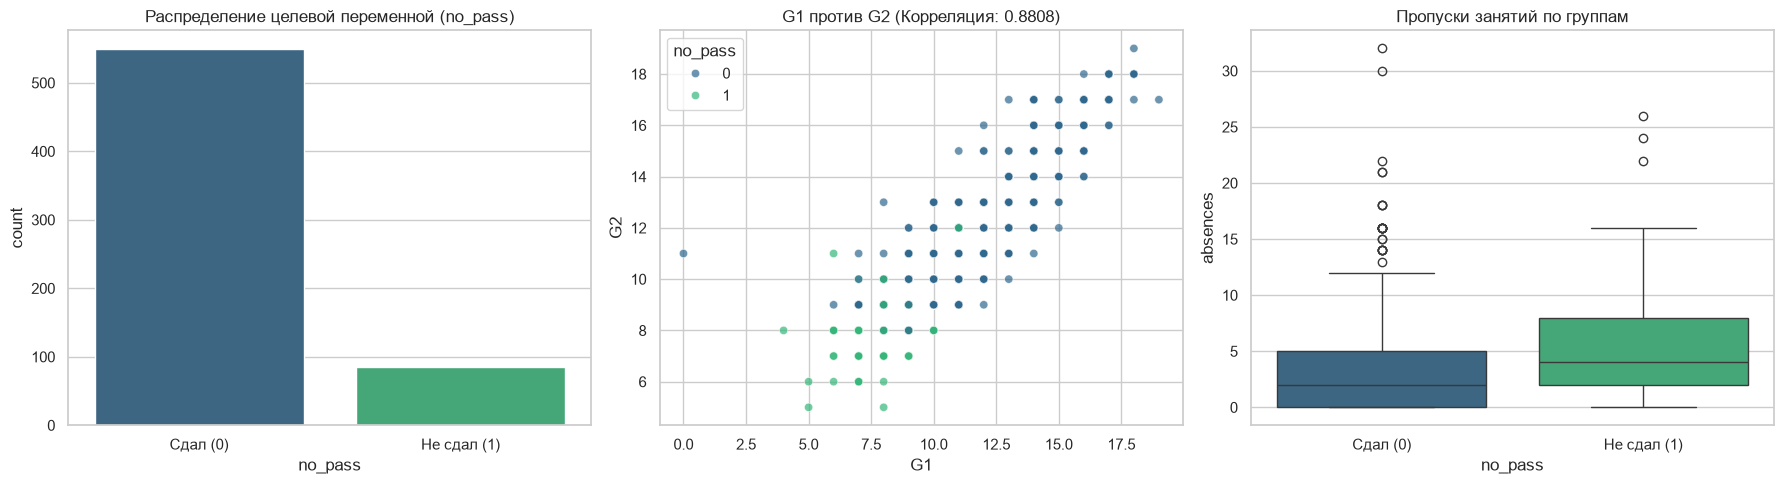

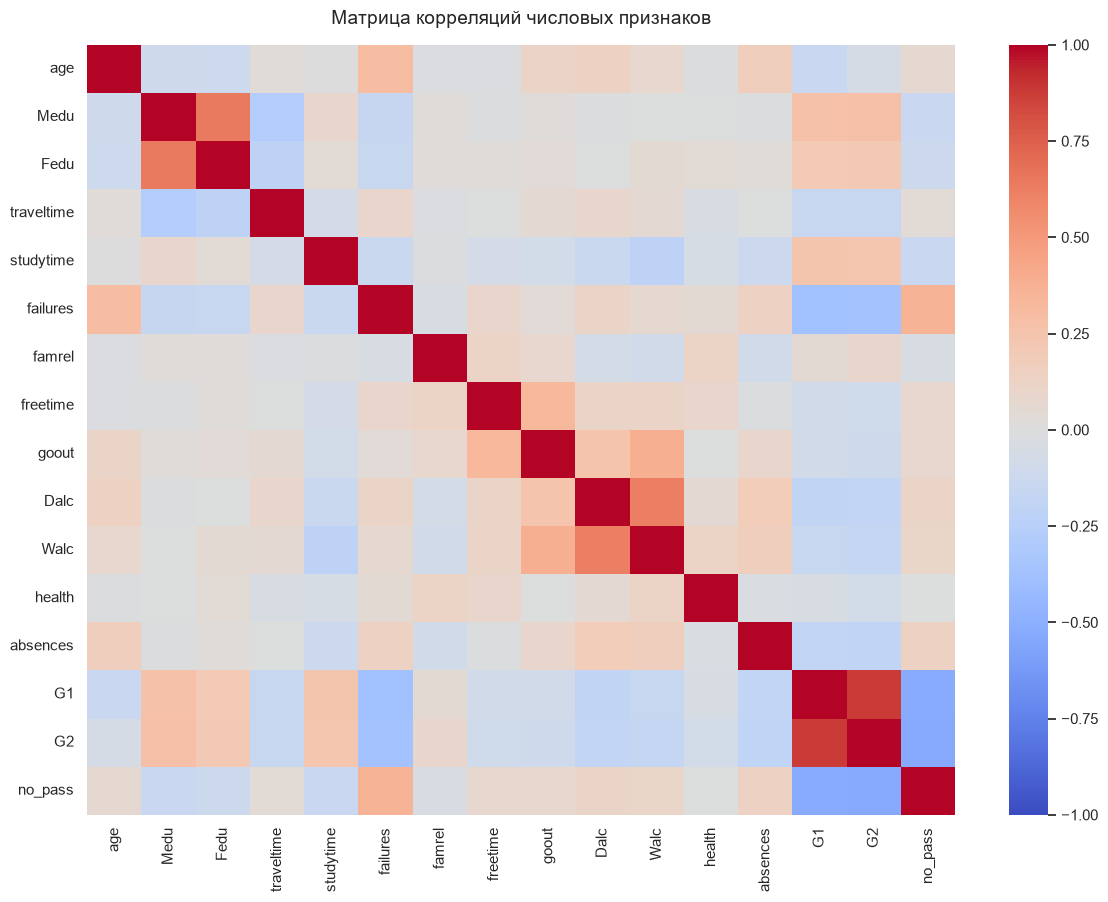

Распределение целевой переменной:
Сдали (0):   86.6%
Не сдали (1): 13.4%


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Распределение целевой переменной
sns.countplot(x='no_pass', data=df_por, ax=axes[0], palette='viridis')
axes[0].set_title('Распределение целевой переменной (no_pass)')
axes[0].set_xticklabels(['Сдал (0)', 'Не сдал (1)'])

# 2. Мультиколлинеарность оценок (G1 против G2)
sns.scatterplot(x='G1', y='G2', hue='no_pass', data=df_por, ax=axes[1], palette='viridis', alpha=0.7)
axes[1].set_title(f'G1 против G2 (Корреляция: {df_por[["G1", "G2"]].corr().iloc[0, 1]:.4f})')

# 3. Выбросы по пропускам занятий
sns.boxplot(x='no_pass', y='absences', data=df_por, ax=axes[2], palette='viridis')
axes[2].set_title('Пропуски занятий по группам')
axes[2].set_xticklabels(['Сдал (0)', 'Не сдал (1)'])

plt.tight_layout() # Автоматически выравнивает отступы между графиками
plt.show()

# --- ОТДЕЛЬНЫЙ БЛОК ДЛЯ МАТРИЦЫ КОРРЕЛЯЦИЙ ---
plt.figure(figsize=(14, 10)) # Задаем большой размер для хорошей читаемости
numeric_cols = df_por.select_dtypes(include=['int32', 'int64', 'float64'])

# annot=False убирает цифры из ячеек (так как признаков много, цифры будут сливаться).
# Цвет сам покажет силу связи.
sns.heatmap(numeric_cols.corr(), annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Матрица корреляций числовых признаков', fontsize=14, pad=15)
plt.show()

# --- ВЫВОД ТЕКСТОВОЙ СТАТИСТИКИ ---
dist = df_por['no_pass'].value_counts(normalize=True)
print("Распределение целевой переменной:")
print(f"Сдали (0):   {dist[0]:.1%}")
print(f"Не сдали (1): {dist[1]:.1%}")

## 3. Разбиение данных и методология

Мы разделяем датасет на обучающую выборку (85%), которую будем использовать для кросс-валидации и подбора гиперпараметров, и строго отложенную тестовую выборку (hold-out, 15%) для финальной оценки.

Мы обучаем две модели:
- **Уровень 1 (Базовый):** использует все доступные признаки, включая промежуточные оценки (G1, G2).
- **Уровень 2 (Раннее предупреждение):** исключает G1 и G2, чтобы смоделировать прогноз, сделанный в начале семестра.

**Методология обучения:** Для экономии времени гиперпараметры CatBoost были подобраны заранее на этапе исследований. Сейчас модели обучаются внутри цикла 5-фолдовой стратифицированной кросс-валидации (Stratified CV) с уже зафиксированными оптимальными настройками.

**Ансамблирование и калибровка:**  Финальная модель для каждого уровня представляет собой ансамбль из 5 моделей, обученных на фолдах. Для корректной калибровки вероятностей применяется изотоническая регрессия (Isotonic Regression) на out-of-fold (OOF) предсказаниях.

In [15]:
X = df_por.drop(columns=['no_pass'])
y = df_por['no_pass']

X_train_cv, X_holdout, y_train_cv, y_holdout = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

def train_level_fast(X_data, y_data, cat_features, best_params):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    oof_preds_raw = np.zeros(len(y_data))
    fold_models = []
    shap_values_list = []
    fold_roc_aucs = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_data, y_data)):
        X_tr, y_tr = X_data.iloc[train_idx], y_data.iloc[train_idx]
        X_val, y_val = X_data.iloc[val_idx], y_data.iloc[val_idx]

        # 1. Обучаем модель сразу с лучшими параметрами
        fold_model = CatBoostClassifier(**best_params)
        fold_model.fit(X_tr, y_tr, cat_features=cat_features, verbose=0)

        # 2. Делаем OOF предсказания
        preds_raw = fold_model.predict_proba(X_val)[:, 1]
        oof_preds_raw[val_idx] = preds_raw
        fold_models.append(fold_model)
        fold_roc_aucs.append(roc_auc_score(y_val, preds_raw))

        # 3. Считаем SHAP
        explainer = shap.TreeExplainer(fold_model)
        shap_vals = explainer.shap_values(X_val)
        shap_values_list.append((shap_vals, X_val))
        
    return fold_models, oof_preds_raw, shap_values_list, fold_roc_aucs

def analyze_shap(shap_values_list, feature_names):
    ranks_list = []
    for shap_vals, X_val in shap_values_list:
        mean_abs_shap = np.abs(shap_vals).mean(axis=0)
        ranks = pd.Series(mean_abs_shap, index=feature_names).rank(ascending=False)
        ranks_list.append(ranks)
        
    ranks_df = pd.DataFrame(ranks_list)
    top3_counts = (ranks_df <= 3).sum(axis=0)
    
    top3_features = top3_counts.sort_values(ascending=False).head(3).index.tolist()
    return top3_counts.sort_values(ascending=False), top3_features

from sklearn.isotonic import IsotonicRegression

def find_best_threshold(y_true, y_probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-9)
    best_idx = np.argmax(f2_scores)
    if best_idx == len(thresholds):
        best_idx -= 1
    return thresholds[best_idx], f2_scores[best_idx]

def evaluate_ensemble_fast(models, calibrator, X_test, y_test, threshold=0.5):
    probs_raw = np.mean([model.predict_proba(X_test)[:, 1] for model in models], axis=0)
    probs = calibrator.transform(probs_raw)

    roc_auc = roc_auc_score(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    preds = (probs >= threshold).astype(int)
    
    return roc_auc, pr_auc, ci_lower, ci_upper, probs, preds

## 4. Training Level 1 (Baseline)

In [16]:
print("Training Level 1 (All features)...")

params_l1 = {
    'iterations': 500,
    'learning_rate': 0.024717766231491974,
    'depth': 3,
    'l2_leaf_reg': 2.570289951297309,
    'border_count': 204,
    'verbose': 0,
    'auto_class_weights': 'Balanced',
    'random_strength': 5.8193221700204835e-05,
    'bagging_temperature': 0.29405678087944664,
    'random_state': 42,
    'min_data_in_leaf': 6}

models_l1, oof_l1_raw, shap_l1, fold_aucs_l1 = train_level_fast(X_train_cv, y_train_cv, cat_features, params_l1)

calibrator_l1 = IsotonicRegression(out_of_bounds='clip')
oof_l1 = calibrator_l1.fit_transform(oof_l1_raw, y_train_cv)

roc_l1_oof = roc_auc_score(y_train_cv, oof_l1)
pr_l1_oof = average_precision_score(y_train_cv, oof_l1)
thresh_l1, f2_l1 = find_best_threshold(y_train_cv, oof_l1)

print(f"\nOOF ROC-AUC: {roc_l1_oof:.4f}, PR-AUC: {pr_l1_oof:.4f}")
print(f"Средний ROC-AUC на кросс-валидации по фолдам: {np.mean(fold_aucs_l1):.4f} ± {np.std(fold_aucs_l1):.4f}")
print(f"Оптимальный порог (Максимум F2): {thresh_l1:.4f}")

stability_l1, top3_l1 = analyze_shap(shap_l1, X_train_cv.columns)
print("\nСтабильность Топ-3 признаков:")
for feat, count in stability_l1.head(3).items():
    print(f"{feat}: {count}/5 фолдов")

Training Level 1 (All features)...

OOF ROC-AUC: 0.9740, PR-AUC: 0.8573
Средний ROC-AUC на кросс-валидации по фолдам: 0.9714 ± 0.0120
Оптимальный порог (Максимум F2): 0.2000

Стабильность Топ-3 признаков:
G1: 5/5 фолдов
G2: 5/5 фолдов
school: 3/5 фолдов


## 5. Training Level 2 (Early Warning)

In [17]:
print("Training Level 2 (Early Warning - Without G1/G2)...")

# 1. Убираем оценки из обучающей и тестовой выборок
X_train_cv_l2 = X_train_cv.drop(columns=['G1', 'G2'])
X_holdout_l2 = X_holdout.drop(columns=['G1', 'G2'])

params_l2 = {
    'iterations': 500,
    'learning_rate': 0.04943936990074188,
    'depth': 6,
    'l2_leaf_reg': 1.2928477402119334,
    'border_count': 206,
    'verbose': 0,
    'auto_class_weights': 'Balanced',
    'random_strength': 1.5272672721418092e-08,
    'bagging_temperature': 0.5703079336214844,
    'random_state': 42,
    'min_data_in_leaf': 12
}

# 2. Запускаем  функцию обучения
models_l2, oof_l2_raw, shap_l2, fold_aucs_l2 = train_level_fast(X_train_cv_l2, y_train_cv, cat_features, params_l2)

# 3. Калибровка вероятностей
calibrator_l2 = IsotonicRegression(out_of_bounds='clip')
oof_l2 = calibrator_l2.fit_transform(oof_l2_raw, y_train_cv)

roc_l2_oof = roc_auc_score(y_train_cv, oof_l2)
pr_l2_oof = average_precision_score(y_train_cv, oof_l2)
thresh_l2, f2_l2 = find_best_threshold(y_train_cv, oof_l2)

# 4. Вывод метрик
print(f"\nOOF ROC-AUC: {roc_l2_oof:.4f}, PR-AUC: {pr_l2_oof:.4f}")
print(f"Средний ROC-AUC на кросс-валидации по фолдам: {np.mean(fold_aucs_l2):.4f} ± {np.std(fold_aucs_l2):.4f}")
print(f"Оптимальный порог (Максимум F2): {thresh_l2:.4f}")

# 5. Анализ стабильности признаков
stability_l2, top3_l2 = analyze_shap(shap_l2, X_train_cv_l2.columns)
print("\nСтабильность Топ-3 признаков (попаданий в топ по фолдам):")
for feat, count in stability_l2.head(3).items():
    print(f"- {feat}: {count}/5 фолдов")
print(f"Топ-3 фактора Уровня 2: {top3_l2}")

Training Level 2 (Early Warning - Without G1/G2)...

OOF ROC-AUC: 0.8273, PR-AUC: 0.4207
Средний ROC-AUC на кросс-валидации по фолдам: 0.8170 ± 0.0181
Оптимальный порог (Максимум F2): 0.1304

Стабильность Топ-3 признаков (попаданий в топ по фолдам):
- school: 5/5 фолдов
- failures: 5/5 фолдов
- absences: 4/5 фолдов
Топ-3 фактора Уровня 2: ['school', 'failures', 'absences']


## 6. Интерпретация ключевых факторов
Мы исследуем направление влияния топ-3 факторов для каждого уровня.

In [18]:
def print_factor_direction(factors, data):
    for feature in factors:
        if data[feature].dtype in ['int64', 'float64']:
            corr = data[[feature, 'no_pass']].corr().iloc[0, 1]
            direction = "Более высокие" if corr > 0 else "Более низкие"
            print(f"- {feature}: {direction} значения увеличивают риск неуспеваемости (Корреляция: {corr:.3f})")
        else:
            rates = data.groupby(feature)['no_pass'].mean().sort_values(ascending=False)
            print(f"- {feature}: категория '{rates.index[0]}' имеет наивысшую долю неуспеваемости ({rates.iloc[0]:.1%})")

print("Направление влияния топ-факторов Уровня 1:")
print_factor_direction(top3_l1, df_por)

print("\nНаправление влияния топ-факторов Уровня 2:")
print_factor_direction(top3_l2, df_por)

Направление влияния топ-факторов Уровня 1:
- G1: Более низкие значения увеличивают риск неуспеваемости (Корреляция: -0.528)
- G2: Более низкие значения увеличивают риск неуспеваемости (Корреляция: -0.534)
- school: категория 'MS' имеет наивысшую долю неуспеваемости (25.5%)

Направление влияния топ-факторов Уровня 2:
- school: категория 'MS' имеет наивысшую долю неуспеваемости (25.5%)
- failures: Более высокие значения увеличивают риск неуспеваемости (Корреляция: 0.362)
- absences: Более высокие значения увеличивают риск неуспеваемости (Корреляция: 0.142)


## 7. Финальная оценка на отложенной выборке (Hold-Out)

На тестовой выборке наблюдается снижение метрики ROC-AUC по сравнению с результатами кросс-валидации. Это ожидаемое поведение, обусловленное двумя факторами:

   - **Высокая дисперсия на малых данных:** Объем hold-out выборки составляет всего 15% от небольшого исходного датасета (менее 100 студентов). В условиях дисбаланса классов ошибка классификации всего на нескольких объектах миноритарного класса приводит к существенному колебанию итоговой метрики.
   - **Чувствительность изотонической регрессии:** Калибратор мог излишне подстроиться под распределение OOF-предсказаний, что немного нарушило идеальное ранжирование на новых данных.

Тем не менее, базовая способность модели разделять классы остается на приемлемом уровне для практического применения.

In [19]:

roc_h_l1, pr_h_l1, _, _, probs_h_l1, preds_h_l1 = evaluate_ensemble_fast(models_l1, calibrator_l1, X_holdout, y_holdout,
                                                                         thresh_l1)
print(f"Уровень 1 (Holdout) - ROC-AUC: {roc_h_l1:.4f}, PR-AUC: {pr_h_l1:.4f}")

roc_h_l2, pr_h_l2, _, _, probs_h_l2, preds_h_l2 = evaluate_ensemble_fast(models_l2, calibrator_l2, X_holdout_l2,
                                                                         y_holdout, thresh_l2)
print(f"Уровень 2 (Holdout) - ROC-AUC: {roc_h_l2:.4f}, PR-AUC: {pr_h_l2:.4f}")

NameError: name 'ci_lower' is not defined

## 8. Датасет по математике
Применение моделей к датасету по математике без дообучения.

In [12]:
df_mat = load_and_clean_data('student-mat.csv')

# Проверка на утечку данных и пересечение студентов по демографическим признакам
demo_cols = ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'nursery', 'internet']
merged = pd.merge(df_por, df_mat, on=demo_cols, how='inner')
print(f"Примечание: обнаружено {len(merged)} потенциально совпадающих студентов между курсами португальского языка и математики на основе демографии.")
print("Это указывает на то, что оценка переноса на другой домен может быть слегка завышенной из-за частичного совпадения личностей студентов.")

X_mat = df_mat.drop(columns=['no_pass'])
y_mat = df_mat['no_pass']
X_mat_l2 = X_mat.drop(columns=['G1', 'G2'])

roc_mat_l1, pr_mat_l1, _, _, _, _ = evaluate_ensemble_fast(models_l1, calibrator_l1, X_mat, y_mat, thresh_l1)
print(f"\nУровень 1 на датасете по математике (без дообучения) - ROC-AUC: {roc_mat_l1:.4f}")

roc_mat_l2, pr_mat_l2, _, _, _, _ = evaluate_ensemble_fast(models_l2, calibrator_l2, X_mat_l2, y_mat, thresh_l2)
print(f"Уровень 2 на датасете по математике (без дообучения) - ROC-AUC: {roc_mat_l2:.4f}")

Примечание: обнаружено 340 потенциально совпадающих студентов между курсами португальского языка и математики на основе демографии.
Это указывает на то, что оценка переноса на другой домен может быть слегка завышенной из-за частичного совпадения личностей студентов.

Уровень 1 на датасете по математике (без дообучения) - ROC-AUC: 0.9531
Уровень 2 на датасете по математике (без дообучения) - ROC-AUC: 0.6545


# Вывод: Оценка обобщающей способности (Domain Transfer)

Как мы видим, базовая модель (Уровень 1) с промежуточными оценками отлично переносится на другой предмет (математику) почти без потерь (ROC-AUC 0.95). Это логично: текущие оценки универсальны — если студент получает плохие баллы в семестре, он с высокой вероятностью не сдаст итоговый экзамен по любому предмету.

Однако качество модели раннего предупреждения (Уровень 2) заметно проседает (с 0.82 до 0.65). Это напрямую отвечает на вопрос о природе наших топ-3 факторов (школа, прошлые провалы, пропуски): они специфичны для конкретного предмета (гуманитарного). Факторы, ведущие к академической неуспеваемости в языковых дисциплинах, отличаются от причин провала в точных науках.